# Assignment 3: Edges and Hough transform

## Exercise 1: Image derivatives

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import os
from a3_utils import draw_line
# import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline


In [2]:
def gauss(sigma):
    radius = int(np.ceil(3*sigma))
    g = np.zeros(2 * radius + 1, dtype=float)
    x = np.arange(-radius, radius + 1, dtype=float)
    g = (1 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-(x**2) / (2 * sigma**2))
    g /= g.sum()
    return g.reshape((1,-1))

1b)

In [3]:
def gaussdx(sigma):
    radius = int(np.ceil(3*sigma))
    x = np.zeros(2 * radius + 1, dtype=float)
    x = np.arange(-radius, radius + 1, dtype=float)
    y = -x / (np.sqrt(2 * np.pi) * sigma**3) * np.exp(-x**2 / (2 * sigma**2))
    y /= np.sum(np.abs(y))
    return y.reshape((1,-1))

1c)

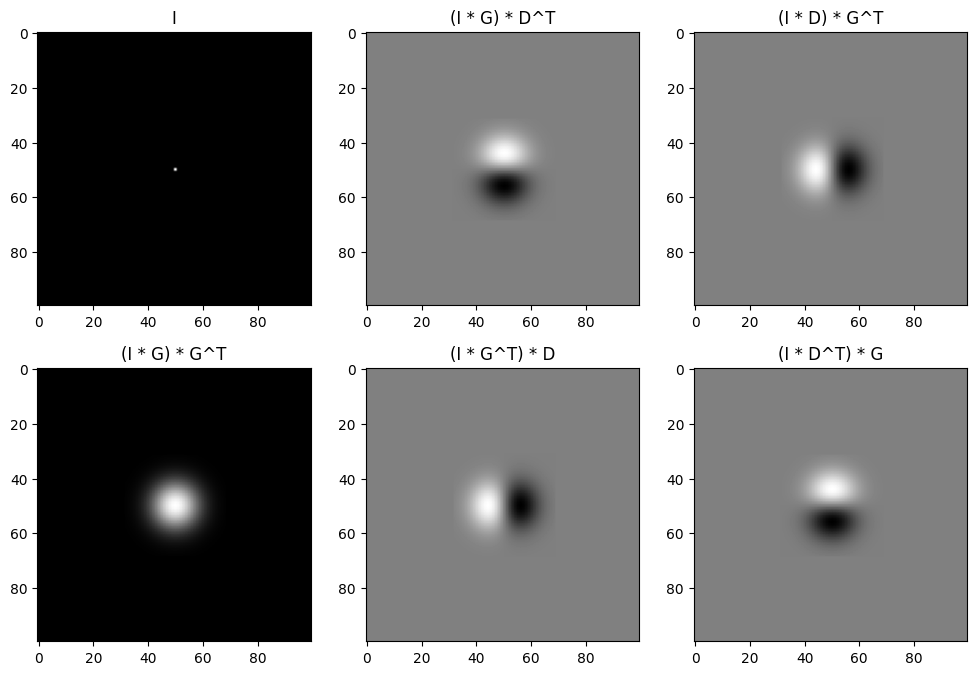

In [4]:
impulse = np.zeros((100,100))
impulse[50,50] = 1

sigma = 6
G = gauss(sigma)
G = np.fliplr(G)
D = gaussdx(sigma)
D = np.fliplr(D)

fig, plot = plt.subplots(2, 3, figsize = (12,8))

plot[0,0].imshow(impulse, cmap='gray')
plot[0,0].set_title('I')

res_a = cv2.filter2D(impulse, -1, G)
res_a = cv2.filter2D(res_a, -1, G.T)
plot[1,0].imshow(res_a, cmap='gray')
plot[1,0].set_title('(I * G) * G^T')

res_b = cv2.filter2D(impulse, -1, G)
res_b = cv2.filter2D(res_b, -1, D.T)
plot[0,1].imshow(res_b, cmap='gray')
plot[0,1].set_title('(I * G) * D^T')

res_c = cv2.filter2D(impulse, -1, D)
res_c = cv2.filter2D(res_c, -1, G.T)
plot[0,2].imshow(res_c, cmap='gray')
plot[0,2].set_title('(I * D) * G^T')

res_d = cv2.filter2D(impulse, -1, G.T)
res_d = cv2.filter2D(res_d, -1, D)
plot[1,1].imshow(res_c, cmap='gray')
plot[1,1].set_title('(I * G^T) * D')

res_e = cv2.filter2D(impulse, -1, D.T)
res_e = cv2.filter2D(res_e, -1, G)
plot[1,2].imshow(res_e, cmap='gray')
plot[1,2].set_title('(I * D^T) * G')

plt.show()

1d)

In [ ]:
def der_x(image, sigma):
    image = image.astype(np.float64)
    d = gaussdx(sigma)
    g = gauss(sigma)

    tmp = cv2.filter2D(image, -1, g.T)
    res = cv2.filter2D(tmp, -1, d)
    return res

def der_y(image, sigma):
    image = image.astype(np.float64)
    d = gaussdx(sigma)
    g = gauss(sigma)

    tmp = cv2.filter2D(image, -1, g)
    res = cv2.filter2D(tmp, -1, d.T)
    return res

def der_xx(image, sigma):
    image = image.astype(np.float64)
    d = gaussdx(sigma)
    g = gauss(sigma)

    first = der_x(image, sigma)
    tmp = cv2.filter2D(first, -1, g.T)
    res = cv2.filter2D(tmp, -1, d)
    return res

def der_yy(image, sigma):
    image = image.astype(np.float64)
    d = gaussdx(sigma)
    g = gauss(sigma)

    first = der_y(image, sigma)
    tmp = cv2.filter2D(first, -1, g)
    res = cv2.filter2D(tmp, -1, d.T)
    return res

def der_xy(image, sigma):
    image = image.astype(np.float64)
    d = gaussdx(sigma)
    g = gauss(sigma)

    first = der_x(image, sigma)
    tmp = cv2.filter2D(first, -1, g)
    res = cv2.filter2D(tmp, -1, d.T)
    return res


In [ ]:
def gradient_magnitude(image, sigma):
    imgx = der_x(image, sigma)
    imgy = der_y(image, sigma)

    m = np.sqrt(imgx**2 + imgy**2)
    angle = np.arctan2(imgy, imgx)
    return (m, angle)

In [ ]:
museum = cv2.imread('./images/museum.jpg')
museum_gray = cv2.cvtColor(museum, cv2.COLOR_BGR2GRAY) / 255.0
sigma = 0.5

plt.figure(figsize=(16,10))
plt.subplot(3, 3, 1)
plt.imshow(museum_gray, cmap='gray')
plt.title('I')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(-der_x(museum_gray, sigma), cmap='gray')
plt.title('Ix')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(-der_y(museum_gray, sigma), cmap='gray')
plt.title('Iy')
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(der_xx(museum_gray, sigma), cmap='gray')
plt.title('Ixx')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(der_yy(museum_gray, sigma), cmap='gray')
plt.title('Iyy')
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(der_xy(museum_gray, sigma), cmap='gray')
plt.title('Ixy')
plt.axis('off')

img_mag, img_dir = gradient_magnitude(museum_gray, sigma)
plt.subplot(3, 3, 7)
plt.imshow(img_mag, cmap='gray')
plt.title('Imag')
plt.axis('off')

plt.subplot(3, 3, 8)
plt.imshow(img_dir, cmap='gray')
plt.title('Idir')
plt.axis('off')

H = (img_dir + np.pi) / (2 * np.pi)
V = img_mag / img_mag.max()
S = np.ones_like(H)

hsv = np.stack([H, S, V], axis=-1)
rgb = colors.hsv_to_rgb(hsv)

plt.subplot(3, 3, 9)
plt.imshow(rgb)
plt.title('Idir (HSV)')
plt.axis('off')

plt.show()

1e

In [ ]:
def myhist4(image, n_bins, sigma):
    n_grid = 8
    mag, ang = gradient_magnitude(image, sigma)
    h, w = image.shape
    grid_h = h // n_grid
    grid_w = w // n_grid

    hist = np.zeros((n_grid*n_grid, n_bins))

    for i in range (n_grid):
        for j in range (n_grid):
            cell_mag = mag[i * grid_h : (i + 1) * grid_h, j * grid_w : (j + 1) * grid_w]
            cell_ang = ang[i * grid_h : (i + 1) * grid_h, j * grid_w: (j + 1) * grid_w]

            ang01 = (cell_ang + np.pi) / (2 * np.pi)
            bins = (ang01 * 8).astype(int)
            bins = np.clip(bins, 0, 7)

            for y in range(grid_h):
                for x in range(grid_w):
                    b = bins[y, x]
                    hist[i*n_grid + j, b] += cell_mag[y, x]

    return hist.flatten()

In [ ]:
def compare_histograms(hist1, hist2, operation):
    hist1 = np.asarray(hist1, dtype=np.float64).ravel()
    hist2 = np.asarray(hist2, dtype=np.float64).ravel()

    if operation == 'L2':
        distance = np.sqrt(np.sum((hist1 - hist2) ** 2))
        return distance
    elif operation == 'X2':
        e0 = 1e-10
        chi = 0.5 * np.sum(((hist1 - hist2) ** 2) / (hist1 + hist2 + e0))
        return chi
    elif operation == 'I':
        intersection = 1 - np.sum(np.minimum(hist1, hist2))
        return intersection
    elif operation == 'H':
        hellinger = np.sqrt(0.5 * np.sum((np.sqrt(hist1) - np.sqrt(hist2)) ** 2))
        return hellinger
    else:
        print("Invalid operation")
        return None

def compute_distances(histogram, metric, all_hists):
    distances = []
    distances = np.array([compare_histograms(histogram, h, metric) for h in all_hists])
    distances = np.array(distances)
    return distances

def save_info(path, n_bins, sigma):
    all_hists = []
    images = sorted([img for img in os.listdir(path) if img.endswith('.png')])
    for i in images:
        full_path = os.path.join(path, i)
        img = cv2.imread(full_path)
        img = (cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)).astype(np.float64)/255.0
        hist = myhist4(img, n_bins, sigma)
        all_hists.append(hist)
    all_hists = np.array(all_hists)
    names = np.array(images)
    parent_dir = os.path.dirname(path)
    np.save(os.path.join(parent_dir, 'histograms.npy'), all_hists)
    np.save(os.path.join(parent_dir, 'hist_names.npy'), names)


def compare_withAll(ref_hist, metric, all_hists):
    hist_names = np.load('hist_names.npy')
    dataset_dir = "./dataset"
    ref_name = "object_05_4.png"
    cols = 6
    N, D = all_hists.shape

    distances = compute_distances(ref_hist, metric, all_hists)

    order = np.argsort(distances)
    first5_idx = order[:6]
    first5_names = hist_names[first5_idx]
    first5_hists = all_hists[first5_idx]
    first5_dists = distances[first5_idx]

    fig, ax = plt.subplots(2, cols, figsize=(16, 6))

    for j, (name, d, h) in enumerate(zip(first5_names, first5_dists, first5_hists)):
        img = cv2.cvtColor(cv2.imread(os.path.join(dataset_dir, name)), cv2.COLOR_BGR2RGB).astype(np.float32)/255.0

        ax[0, j].imshow(img)
        ax[0, j].set_title(f"{name}\n{metric}: {d:.3f}", fontsize=10)

        ax[1, j].bar(np.arange(D), h, width=4)
        ax[1, j].set_xlim(-20, D - 1)

    plt.tight_layout()
    plt.show()



In [ ]:
save_info('./dataset', n_bins=8, sigma=1)

all_hists = np.load('histograms.npy')
hist_names = np.load('hist_names.npy')

query = cv2.imread('./dataset/object_27_1.png')
query = cv2.cvtColor(query, cv2.COLOR_BGR2GRAY)/255.0
query_feat = myhist4(query, 8, 1)

compare_withAll(query_feat, 'H', all_hists)


## Exercise 2: Edges in images

2a

In [ ]:
def findedges(image, sigma, theta):
    Imag, _ = gradient_magnitude(image, sigma)
    Ie = np.where(Imag >= theta, 1, 0)
    return Ie

In [ ]:
museum = cv2.imread('images/museum.jpg')
museum_gray = cv2.cvtColor(museum, cv2.COLOR_BGR2GRAY) / 255.0

plt.figure(figsize=(12,8))
for i, t in enumerate([0.03, 0.07, 0.15, 0.2]):
    Ie = findedges(museum_gray, sigma=1, theta=t)
    plt.subplot(2, 2, i+1)
    plt.imshow(Ie, cmap='gray')
    plt.title(f"theta = {t}")

2b

In [ ]:
def nonmaxima_suppression(img, sigma):
    mag, angle = gradient_magnitude(img, sigma)
    imgnms = np.zeros(img.shape)

    for y in range(1, img.shape[0]-1):
        for x in range(1, img.shape[1]-1):
            ang = (np.rad2deg(angle[y,x]) + 22.5) % 180
            val = mag[y, x]
            m1, m2 = 0, 0

            # horizontal -
            if 0 <= ang < 45:
                m1, m2 = mag[y, x-1], mag[y, x+1]
            # diagonal /
            if 45 <= ang < 90:
                m1, m2 = mag[y-1, x-1], mag[y+1, x+1]
            # vertical |
            if 90 <= ang < 135:
                m1, m2 = mag[y-1, x], mag[y+1, x]
            # diagonal \
            if 135 <= ang < 180:
                m1, m2 = mag[y-1, x+1], mag[y+1, x-1]

            if val >= m1 and val >= m2:
                imgnms[y, x] = val

    return imgnms

2c

In [ ]:
def hysteresis(img, t_low, t_high, sigma):
    imgnms = nonmaxima_suppression(img, sigma)

    imglow = np.where(t_low <= imgnms, 1, 0)
    imghigh = np.where(t_high <= imgnms, 1, 0)

    imghysteresis = np.copy(imghigh)
    n, labels, _, _ = cv2.connectedComponentsWithStats(imglow.astype(np.uint8), connectivity=8)

    for i in range(1,n):
        if np.any(imghigh[labels == i]) > 0:
            imghysteresis[labels == i] = 1

    return imghysteresis

In [ ]:
edges = findedges(museum_gray, 1, 0.16)

image = cv2.imread('./images/museum.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float64)/255
threshold = 0.16
edges_nms = np.where(nonmaxima_suppression(image, sigma) >= threshold, 1, 0)
I_hysteresis = hysteresis(image, 0.04, 0.16, 1)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(museum_gray, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Thresholded (thr = 0,16)')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(edges_nms, cmap='gray')
plt.title('Nonmax. supp. (thr = 0.16)')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(I_hysteresis, cmap='gray')
plt.title('Hysteresis (high = 0.16, low = 0.04)')
plt.axis('off')

plt.show()

## Exercise 3: Detecting lines

**Question: Analytically solve the problem by using Hough transform: In 2D space
you are given four points (0, 0), (1, 1), (1, 0), (2, 2). Define the equations of the lines that
run through at least two of these points.**
Solved in my notes.

3a

In [ ]:
def hough_single_point(x, y, width, height, bins_rho, bins_theta):
    d = np.sqrt(height ** 2 + width ** 2)
    theta_vals = np.linspace(-np.pi/2, np.pi/2, bins_theta)
    rho_vals = np.linspace(-d, d, bins_rho)
    drho = rho_vals[1] - rho_vals[0]

    A = np.zeros((bins_rho, bins_theta), dtype=np.int32)

    for j, theta in enumerate(theta_vals):
        rho = x * np.cos(theta) + y * np.sin(theta)
        i = int(np.round((rho + d) / drho))

        if 0 <= i < bins_rho:
            A[i, j] += 1

    plt.figure()
    plt.imshow(np.zeros((height, width)), cmap='gray')

    for j, theta in enumerate(theta_vals):
        for i, rho in enumerate(rho_vals):
            if A[i, j] > 0:
                rho_val = rho_vals[i]
                theta_val = theta_vals[j]
                draw_line(rho_val, theta_val, height, width, clr='green')

    plt.plot(x, y, 'y*', markersize=10)

    return A, rho_vals, theta_vals

In [ ]:
A, rho_vals, theta_vals = hough_single_point(x=50, y=90, width=100, height=100, bins_rho=300,bins_theta=100)

plt.figure()
plt.imshow(A, aspect='auto')

plt.show()


3b

In [ ]:
def hough_find_lines(image, bins_theta, bins_rho, threshold):
    h, w = image.shape
    d = np.sqrt(h ** 2 + w ** 2) # image diagonal
    theta_vals = np.linspace(-np.pi/2, np.pi/2, bins_theta)
    rho_vals = np.linspace(-d, d, bins_rho)
    d_rho = rho_vals[1] - rho_vals[0]
    A = np.zeros((bins_rho, bins_theta))

    for y in range(h):
        for x in range(w):
            if image[y,x] != 0:
                for theta_idx, theta in enumerate(theta_vals):
                    rho = x * np.cos(theta) + y * np.sin(theta)
                    rho_idx = int(np.round((rho + d) / d_rho))
                    rho_idx = np.clip(rho_idx, 0, bins_rho-1)
                    A[rho_idx, theta_idx] += 1

    A[A < threshold] = 0

    return A


In [ ]:
def hough_find_lines2(edges, bins_rho=300, bins_theta=300, threshold=0.0):
    h, w = edges.shape
    d = np.sqrt(h ** 2 + w ** 2)
    theta_vals = np.linspace(-np.pi/2, np.pi/2, bins_theta)
    rho_vals   = np.linspace(-d, d, bins_rho)
    d_rho = rho_vals[1] - rho_vals[0]

    cos_t = np.cos(theta_vals)
    sin_t = np.sin(theta_vals)

    A = np.zeros((bins_rho, bins_theta), dtype=np.int32)

    ys, xs = np.nonzero(edges)

    for x, y in zip(xs, ys):
        rhos = x * cos_t + y * sin_t
        rho_idx = np.round((rhos + d) / d_rho).astype(int)
        valid = (rho_idx >= 0) & (rho_idx < bins_rho)
        A[rho_idx[valid], np.arange(bins_theta)[valid]] += 1

    A[A < threshold] = 0

    return A

In [ ]:
height, width = 100, 100
I = np.zeros((height, width), dtype=np.uint8)
I[10, 10] = 255
I[10, 20] = 255

oneline = cv2.imread('images/oneline.png')
oneline = cv2.cvtColor(oneline, cv2.COLOR_BGR2GRAY) / 255.0
rectangle = cv2.imread('images/rectangle.png')
rectangle = cv2.cvtColor(rectangle, cv2.COLOR_BGR2GRAY) / 255.0

edges_oneline = findedges(oneline, 1, 0.07)
edges_rectangle = findedges(rectangle, 1, 0.07)

A = hough_find_lines(I, bins_rho=200, bins_theta=180, threshold=0.5)
B = hough_find_lines(edges_oneline, bins_rho=200, bins_theta=180, threshold=0.5)
C = hough_find_lines(edges_rectangle, bins_rho=200, bins_theta=180, threshold=0.5)

# A = hough_find_lines2(I, bins_rho=200, bins_theta=180, threshold=0.5)
# B = hough_find_lines2(edges_oneline, bins_rho=200, bins_theta=180, threshold=0.5)
# C = hough_find_lines2(edges_rectangle, bins_rho=200, bins_theta=180, threshold=0.5)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(A, aspect='auto')
ax[0].set_title('synthetic')

ax[1].imshow(B, aspect='auto')
ax[1].set_title('oneline.png')

ax[2].imshow(C, aspect='auto')
ax[2].set_title('rectangle.png')

3c

In [ ]:
def nonmaxima_suppression_box(imgh, k):
    r = k // 2
    h, w = imgh.shape

    imgh_pad = np.pad(imgh, r, mode='reflect')
    res = np.zeros_like(imgh)

    for y in range(h):
        for x in range(w):
            window = imgh_pad[y : y + 2*r + 1, x : x + 2*r + 1]
            center = imgh[y, x]

            if center == 0:
                continue

            vals = window[window > 0]
            if vals.size == 0:
                continue

            maxval = np.max(vals)

            if center == maxval:
                res[y, x] = center

    return res

In [ ]:
height, width = 100, 100
I = np.zeros((height, width), dtype=np.uint8)
I[10, 10] = 255
I[10, 20] = 255

oneline = cv2.imread('images/oneline.png')
oneline = cv2.cvtColor(oneline, cv2.COLOR_BGR2GRAY) / 255.0
rectangle = cv2.imread('images/rectangle.png')
rectangle = cv2.cvtColor(rectangle, cv2.COLOR_BGR2GRAY) / 255.0

edges_oneline = findedges(oneline, 1, 0.07)
edges_rectangle = findedges(rectangle, 1, 0.07)

synthetich = hough_find_lines2(I, bins_rho=200, bins_theta=180, threshold=0.5)
onelineh = hough_find_lines2(edges_oneline, bins_rho=200, bins_theta=180, threshold=0.5)
rectangleh = hough_find_lines2(edges_rectangle, bins_rho=200, bins_theta=180, threshold=0.5)

synthetic_nmsb = nonmaxima_suppression_box(synthetich, 3)
oneline_nmsb = nonmaxima_suppression_box(onelineh, 3)
rectangle_nmsb = nonmaxima_suppression_box(rectangleh, 3)


fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(synthetic_nmsb, aspect='auto')
ax[0].set_title('synthetic')

ax[1].imshow(oneline_nmsb, aspect='auto')
ax[1].set_title('oneline.png')

ax[2].imshow(rectangle_nmsb, aspect='auto')
ax[2].set_title('rectangle.png')

3d

In [ ]:
def hough_draw_lines(image, bins_rho=300, bins_theta=300, hough_thr=0, k_box=3, line_thr=100, ax = None):
    h, w = image.shape
    d = np.sqrt(h**2 + w**2)

    rho_vals   = np.linspace(-d, d, bins_rho)
    theta_vals = np.linspace(-np.pi/2, np.pi/2, bins_theta)

    image_edges = findedges(image, 1, 0.07)

    A = hough_find_lines2(image_edges, bins_theta, bins_rho, hough_thr)
    A_nms = nonmaxima_suppression_box(A, k_box)
    height, width = A_nms.shape

    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(image, cmap="gray")
    plt.sca(ax)

    for r in range(height):
        for t in range(width):
            if A_nms[r, t] >= line_thr:
                rho = rho_vals[r]
                theta = theta_vals[t]
                draw_line(rho, theta, h, w)

    return A


In [ ]:
height, width = 100, 100
synthetic = np.zeros((height, width), dtype=np.uint8)
synthetic[10, 10] = 1
synthetic[10, 20] = 1

oneline = cv2.imread('images/oneline.png')
oneline = cv2.cvtColor(oneline, cv2.COLOR_BGR2GRAY) / 255.0
rectangle = cv2.imread('images/rectangle.png')
rectangle = cv2.cvtColor(rectangle, cv2.COLOR_BGR2GRAY) / 255.0

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
_ = hough_draw_lines(synthetic, bins_rho=300, bins_theta=300, hough_thr=0, k_box=5, line_thr=6, ax=ax[0])
_ = hough_draw_lines(oneline, bins_rho=300, bins_theta=300, hough_thr=0, k_box=5, line_thr=90, ax=ax[1])
_ = hough_draw_lines(rectangle, bins_rho=300, bins_theta=300, hough_thr=0, k_box=5, line_thr=105,ax=ax[2])


3e

In [ ]:
def hough_draw_top10_lines(image, bins_rho=200, bins_theta=180, hough_thr=0, k_box=3):
    h, w = image.shape
    d = np.sqrt(h**2 + w**2)

    rho_vals   = np.linspace(-d, d, bins_rho)
    theta_vals = np.linspace(-np.pi/2, np.pi/2, bins_theta)

    image_edges = findedges(image, 1, 0.07)

    A = hough_find_lines2(image_edges, bins_rho, bins_theta, hough_thr)
    A_nms = nonmaxima_suppression_box(A, k_box)

    sorted = np.argsort(A_nms.ravel())[::-1][:10]
    topidx = np.column_stack(np.unravel_index(sorted, A_nms.shape))

    return A, topidx, rho_vals, theta_vals

In [ ]:
bricks = cv2.cvtColor(cv2.imread('./images/bricks.jpg'), cv2.COLOR_BGR2RGB)
bricks_gray = cv2.cvtColor(bricks, cv2.COLOR_RGB2GRAY) / 255
rectangle = cv2.cvtColor(cv2.imread('./images/pier.jpg'), cv2.COLOR_BGR2RGB)
pier_gray = cv2.cvtColor(rectangle, cv2.COLOR_RGB2GRAY) / 255

bricks_A, topidx_bricks, rho_vals, theta_vals = hough_draw_top10_lines(bricks_gray)
h, w = bricks_gray.shape


fig, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0, 0].imshow(bricks_A)
ax[0, 0].set_title('bricks.jpg')
ax[1, 0].imshow(bricks)
plt.sca(ax[1,0])

for y,x in topidx_bricks:
    rho = rho_vals[y]
    theta = theta_vals[x]
    draw_line(rho, theta, h, w, clr='r', linewidth=1.5)

pier_A, topidx_pier, rho_vals, theta_vals = hough_draw_top10_lines(pier_gray)
h, w = pier_gray.shape

ax[0, 1].imshow(pier_A)
ax[0, 1].set_title('pier.jpg')
ax[1, 1].imshow(rectangle)
plt.sca(ax[1,1])

for y,x in topidx_pier:
    rho = rho_vals[y]
    theta = theta_vals[x]
    draw_line(rho, theta, h, w, clr='r', linewidth=1.5)


3f

In [ ]:
def findedges2(image, sigma, theta):
    Imag, ang = gradient_magnitude(image, sigma)
    Ie = np.where(Imag >= theta, 1, 0)
    return Ie, ang

In [ ]:
# ines in the direction of the gradient are unlikely to be
# good candidates, while those perpendicular to the gradient are much more likely to
# have a higher support.

def hough_find_lines_ang(edges, angles, bins_rho=300, bins_theta=300, threshold=0):
    h, w = edges.shape
    d = np.sqrt(h ** 2 + w ** 2)

    theta_vals = np.linspace(-np.pi/2, np.pi/2, bins_theta)
    rho_vals   = np.linspace(-d, d, bins_rho)
    d_rho = rho_vals[1] - rho_vals[0]

    img_angles = (angles + np.pi/2) % np.pi - np.pi/2
    neighborhood = np.deg2rad(1) #range of angles

    cos_t = np.cos(theta_vals)
    sin_t = np.sin(theta_vals)

    A = np.zeros((bins_rho, bins_theta), dtype=np.int32)

    ys, xs = np.nonzero(edges)

    for x, y in zip(xs, ys):
        theta = img_angles[y, x]
        theta_min = theta - neighborhood
        theta_max = theta + neighborhood

        theta_mask = (theta_vals >= theta_min) & (theta_vals <= theta_max)
        theta_idxs = np.where(theta_mask)[0]

        rhos = x * cos_t[theta_mask] + y * sin_t[theta_mask]
        rho_idx = np.round((rhos + d) / d_rho).astype(int)
        valid = (rho_idx >= 0) & (rho_idx < bins_rho)
        A[rho_idx[valid], theta_idxs[valid]] += 1

    A[A < threshold] = 0

    return A, rho_vals, theta_vals

In [ ]:
rectangle = cv2.imread('images/rectangle.png')
rectangle = cv2.cvtColor(rectangle, cv2.COLOR_BGR2GRAY) / 255.0

bins_rho = 300
bins_theta = 300

# --- Normal Hough ---
edges = findedges(rectangle, 1, 0.07)
A_normal = hough_find_lines2(edges, bins_rho, bins_theta)
A_param = nonmaxima_suppression_box(A_normal, 5)

h, w = rectangle.shape
d = np.sqrt(h**2 + w**2)
rho_vals = np.linspace(-d, d, bins_rho)
theta_vals = np.linspace(-np.pi/2, np.pi/2, bins_theta)

flat = np.argsort(A_normal.ravel())[::-1][:40]
ys, xs = np.unravel_index(flat, A_normal.shape)

# --- Orientation Hough ---
edges2, ang2 = findedges2(rectangle, 1, 0.07)
A_orient, rho_vals2, theta_vals2 = hough_find_lines_ang(edges2, ang2, bins_rho, bins_theta)

flat2 = np.argsort(A_orient.ravel())[::-1][:20]
ys2, xs2 = np.unravel_index(flat2, A_orient.shape)

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Normal Hough space
ax[0,0].imshow(A_normal)
ax[0,0].set_title("normal")

# Normal lines
ax[1,0].imshow(rectangle, cmap='gray')
plt.sca(ax[1,0])
for y, x in zip(ys, xs):
    rho = rho_vals[y]
    theta = theta_vals[x]
    draw_line(rho, theta, h, w, clr='r')

# Orientation Hough space
ax[0,1].imshow(A_orient)
ax[0,1].set_title("orientation")

# Orientation lines
ax[1,1].imshow(rectangle, cmap='gray')
plt.sca(ax[1,1])
for y, x in zip(ys2, xs2):
    rho = rho_vals[y]
    theta = theta_vals[x]
    draw_line(rho, theta, h, w, clr='r')

plt.show()


3g

In [ ]:
def hough_find_circles(img, r=48, bins_theta=90):
    edges = findedges(img, 1, 0.07)
    ys, xs = np.nonzero(edges)
    thetas = np.linspace(0, 2*np.pi, bins_theta)
    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)
    h, w = img.shape
    A = np.zeros((w, h))

    for y, x in zip(ys, xs):
        for ct, st in zip(cos_t, sin_t):
            a = int(x - r * ct)
            b = int(y - r * st)

            if 0 <= a < w and 0 <= b < h:
                A[a, b] += 1

    return A

In [ ]:
eclipse = cv2.imread('./images/eclipse.jpg')
eclipse = cv2.cvtColor(eclipse, cv2.COLOR_BGR2RGB)
coins = cv2.imread('./images/coins.jpg')
coins = cv2.cvtColor(coins, cv2.COLOR_BGR2RGB)

eclipsef = cv2.Canny(eclipse, 100, 200)
_, plot = plt.subplots(1,2, figsize=(10,10))
eclipseh = hough_find_circles(eclipsef)
plot[0].imshow(eclipseh)
eclipse_nms = nonmaxima_suppression_box(eclipseh, 5)
threshold = 40
ys, xs = np.where(eclipse_nms >= threshold)

plot[1].imshow(eclipse)

for y, x in zip(ys, xs):
    if eclipseh[y,x] >= threshold:
        c = plt.Circle((y,x), 48, fill=False, color="green")
        plot[1].add_patch(c)

In [ ]:
# coins = cv2.imread('./images/coins.jpg')
# coins = cv2.cvtColor(coins, cv2.COLOR_BGR2RGB)
#
# coinsf = cv2.Canny(coins, 100, 200)
# _, plot = plt.subplots(1,2, figsize=(10,10))
# coinsh = hough_find_circles(coinsf)
# plot[0].imshow(coinsh)
# coins_nms = nonmaxima_suppression_box(coinsh, 5)
# threshold = 80
# ys, xs = np.where(coins_nms >= threshold)
#
# plot[1].imshow(coins)
#
# for y, x in zip(ys, xs):
#     if coinsh[y,x] >= threshold:
#         c = plt.Circle((y,x), 48, fill=False, color="green")
#         plot[1].add_patch(c)

3h

In [ ]:
def norm(rho, theta, width, height):
    points = []

    if np.sin(theta) != 0:
        yL = rho / np.sin(theta)    # x==0
        if 0 <= yL < height:
            points.append((0, yL))
        yR = (rho - (width - 1) * np.cos(theta)) / np.sin(theta)
        if 0 <= yR < height:    # x == width - 1
            points.append((width - 1, yR))

    if np.cos(theta) != 0:
        xT = rho / np.cos(theta)
        if 0 <= xT < width:
            points.append((xT, 0))  # y==0
        xB = (rho - (height - 1) * np.sin(theta)) / np.cos(theta)
        if 0 <= xB < width:
            points.append((xB, height - 1)) # y == height - 1

    if len(points) == 0:
        return 0

    max_L = 0.0
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            x1, y1 = points[i]
            x2, y2 = points[j]
            L = np.hypot(x2 - x1, y2 - y1)
            if L > max_L:
                max_L = L
    return 1 / max_L if max_L != 0 else 0.0

In [ ]:
#Not all lines can accumulate the same number of votes, e.g. if the
# image is not square, candidates along the longer dimension are in better position
# since there are more pixels that can vote for them.
def hough_find_lines_normalised(edges, bins_rho=300, bins_theta=300, threshold=0):
    h, w = edges.shape
    d = np.sqrt(h ** 2 + w ** 2)

    theta_vals = np.linspace(-np.pi/2, np.pi/2, bins_theta)
    rho_vals   = np.linspace(-d, d, bins_rho)
    d_rho = rho_vals[1] - rho_vals[0]

    cos_t = np.cos(theta_vals)
    sin_t = np.sin(theta_vals)

    A = np.zeros((bins_rho, bins_theta), dtype=float)
    ys, xs = np.nonzero(edges)

    for x, y in zip(xs, ys):
        rhos = x * cos_t + y * sin_t
        rho_idx = np.round((rhos + d) / d_rho).astype(int)
        valid = (rho_idx >= 0) & (rho_idx < bins_rho)
        for j in np.where(valid)[0]:
            i = rho_idx[j]
            A[i, j] += norm(rho_vals[i], theta_vals[j], w, h)

    A[A < threshold] = 0

    return A

In [ ]:
rectangle = cv2.imread('images/rectangle.png')
rectangle = cv2.cvtColor(rectangle, cv2.COLOR_BGR2GRAY)
bins_rho = 300
bins_theta = 300

# Normal
edges = cv2.Canny(rectangle, 100, 200)
A_normal = hough_find_lines2(edges, bins_rho, bins_theta)

h, w = rectangle.shape
d = np.sqrt(h**2 + w**2)
rho_vals = np.linspace(-d, d, bins_rho)
theta_vals = np.linspace(-np.pi/2, np.pi/2, bins_theta)
flat = np.argsort(A_normal.ravel())[::-1][:40]
ys, xs = np.unravel_index(flat, A_normal.shape)

# Normalised
A_norm = hough_find_lines_normalised(edges, bins_rho, bins_theta)
flatN = np.argsort(A_norm.ravel())[::-1][:40]
ysN, xsN = np.unravel_index(flatN, A_norm.shape)

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Normal Hough space
ax[0,0].imshow(A_normal)
ax[0,0].set_title("Normal Hough")

# Normalised Hough space
ax[0,1].imshow(A_norm)
ax[0,1].set_title("Normalised Hough")

# Normal
ax[1,0].imshow(rectangle, cmap='gray')
plt.sca(ax[1,0])
for y, x in zip(ys, xs):
    rho = rho_vals[y]
    theta = theta_vals[x]
    draw_line(rho, theta, h, w, clr='r')

# Normalised
ax[1,1].imshow(rectangle, cmap='gray')
plt.sca(ax[1,1])
for y, x in zip(ysN, xsN):
    rho = rho_vals[y]
    theta = theta_vals[x]
    draw_line(rho, theta, h, w, clr='r')

plt.show()